In [10]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from torch import nn, optim
from torch.utils.data import Dataset, DataLoader, random_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
import random
import os

# For reproducibility
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)

# Config
INPUT_DIM = 128
OUTPUT_DIM = 8
SEQ_LEN = 12
PRED_LEN = 5
EPOCHS = 100   # You can set higher for best results
BATCH_SIZE = 50
LR = 5e-5
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


In [11]:
class CSIDataset(Dataset):
    def __init__(self, file_path):
        self.df = pd.read_csv(file_path, header=None)
        self.scaler = StandardScaler()
        self.data = self.scaler.fit_transform(self.df.values)
    def __len__(self):
        return len(self.data) - SEQ_LEN - PRED_LEN
    def __getitem__(self, idx):
        x = self.data[idx:idx+SEQ_LEN]
        y = self.data[idx+SEQ_LEN:idx+SEQ_LEN+PRED_LEN]
        return torch.FloatTensor(x), torch.FloatTensor(y)

# CHANGE PATH for your scenario
file_path = r"C:\Users\Aftab Dayer\Desktop\Thesis\dataset\UMA_128.csv" # e.g., 3kmph or 30kmph

dataset = CSIDataset(file_path)
n = len(dataset)
n_train = int(0.7 * n)
n_val = int(0.15 * n)
n_test = n - n_train - n_val
train_set, val_set, test_set = random_split(dataset, [n_train, n_val, n_test], generator=torch.Generator().manual_seed(seed))
train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_set, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False)


In [12]:
import torch.nn.functional as F

class GraphAttentionLayer(nn.Module):
    def __init__(self, in_dim, out_dim, heads=4):
        super().__init__()
        self.heads = heads
        self.W = nn.Linear(in_dim, heads*out_dim, bias=False)
        self.a = nn.Parameter(torch.randn(2*out_dim, 1))
    def forward(self, h):
        Wh = self.W(h).view(*h.shape[:2], self.heads, -1)
        e = torch.matmul(Wh, Wh.transpose(2,3)) / np.sqrt(Wh.size(-1))
        attention = F.softmax(e, dim=-1)
        h_prime = torch.matmul(attention, Wh)
        return F.elu(h_prime.view(*h.shape[:2], -1))

class EnhancedGAT(nn.Module):
    def __init__(self):
        super().__init__()
        self.gat1 = GraphAttentionLayer(INPUT_DIM, 32)
        self.gat2 = GraphAttentionLayer(128, 64)
        self.tcn = nn.Conv1d(INPUT_DIM, 256, kernel_size=3, padding=1)
        self.fc = nn.Sequential(
            nn.Linear(256 + 256, 512),
            nn.ReLU(),
            nn.Linear(512, OUTPUT_DIM)
        )
    def forward(self, x):
        x_gat = self.gat1(x)
        x_gat = self.gat2(x_gat)
        x_tcn = self.tcn(x.permute(0,2,1))
        x_tcn = x_tcn.permute(0,2,1)
        combined = torch.cat([x_gat, x_tcn], dim=-1)
        return self.fc(combined[:, -1, :])


In [13]:
class LSTMNet(nn.Module):
    def __init__(self, input_dim=128, hidden_dim=64, output_dim=8, num_layers=2):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)
    def forward(self, x):
        _, (hn, _) = self.lstm(x)
        out = hn[-1]
        return self.fc(out)


In [14]:
class CNNNet(nn.Module):
    def __init__(self, input_dim=128, output_dim=8):
        super().__init__()
        self.conv1 = nn.Conv1d(input_dim, 64, kernel_size=3, padding=1)
        self.relu = nn.ReLU()
        self.conv2 = nn.Conv1d(64, 32, kernel_size=3, padding=1)
        self.fc = nn.Linear(32, output_dim)
    def forward(self, x):
        x = x.permute(0,2,1)
        x = self.relu(self.conv1(x))
        x = self.relu(self.conv2(x))
        x = x.mean(dim=2)
        return self.fc(x)


In [15]:
def spectral_efficiency(y_true, y_pred, snr_db=30):
    noise_var = 10 ** (-snr_db / 10)
    signal_power = np.mean(np.linalg.norm(y_pred, axis=1)**2)
    interference = np.mean(np.linalg.norm(y_pred - y_true, axis=1)**2)
    sinr = signal_power / (interference + noise_var)
    return np.log2(1 + sinr)


In [16]:
def validate(model, loader, device, snr_db=30):
    model.eval()
    total_loss, total_rmse, total_se, batches = 0, 0, 0, 0
    criterion = nn.MSELoss()
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            y_true = y[:, -1, :OUTPUT_DIM].to(device)
            y_pred = model(x)
            loss = criterion(y_pred, y_true)
            y_true_np = y_true.cpu().numpy()
            y_pred_np = y_pred.detach().cpu().numpy()
            rmse = np.sqrt(mean_squared_error(y_true_np, y_pred_np))
            se = spectral_efficiency(y_true_np, y_pred_np, snr_db)
            total_loss += loss.item()
            total_rmse += rmse
            total_se += se
            batches += 1
    return total_loss / batches, total_rmse / batches, total_se / batches


In [17]:
def train_model(model, train_loader, val_loader, device, epochs=100, lr=5e-5, model_name='model'):
    optimizer = optim.RMSprop(model.parameters(), lr=lr, weight_decay=1e-5)
    criterion = nn.MSELoss()
    best_val_rmse = float('inf')
    history = {'train_loss': [], 'val_loss': [], 'train_rmse': [], 'val_rmse': [], 'train_se': [], 'val_se': []}

    for epoch in range(epochs):
        model.train()
        total_loss, total_rmse, total_se, batches = 0, 0, 0, 0
        for x, y in train_loader:
            x = x.to(device)
            y_true = y[:, -1, :OUTPUT_DIM].to(device)
            optimizer.zero_grad()
            y_pred = model(x)
            loss = criterion(y_pred, y_true)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            y_true_np = y_true.cpu().numpy()
            y_pred_np = y_pred.detach().cpu().numpy()
            rmse = np.sqrt(mean_squared_error(y_true_np, y_pred_np))
            se = spectral_efficiency(y_true_np, y_pred_np)
            total_loss += loss.item()
            total_rmse += rmse
            total_se += se
            batches += 1
        avg_train_loss = total_loss / batches
        avg_train_rmse = total_rmse / batches
        avg_train_se = total_se / batches

        val_loss, val_rmse, val_se = validate(model, val_loader, device)

        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(val_loss)
        history['train_rmse'].append(avg_train_rmse)
        history['val_rmse'].append(val_rmse)
        history['train_se'].append(avg_train_se)
        history['val_se'].append(val_se)

        print(f"{model_name} | Epoch {epoch+1}/{epochs} | Train Loss: {avg_train_loss:.4f}, RMSE: {avg_train_rmse:.4f}, SE: {avg_train_se:.4f} | Val Loss: {val_loss:.4f}, RMSE: {val_rmse:.4f}, SE: {val_se:.4f}")

        # Save best model (by val RMSE)
        if val_rmse < best_val_rmse:
            best_val_rmse = val_rmse
            torch.save(model.state_dict(), f'{model_name}_best.pth')
            print(f"==> {model_name} best model saved at epoch {epoch+1}")

    return history


In [18]:
# GAT
gat_model = EnhancedGAT().to(DEVICE)
gat_history = train_model(gat_model, train_loader, val_loader, DEVICE, epochs=EPOCHS, lr=LR, model_name='gat')

# LSTM
lstm_model = LSTMNet().to(DEVICE)
lstm_history = train_model(lstm_model, train_loader, val_loader, DEVICE, epochs=EPOCHS, lr=LR, model_name='lstm')

# CNN
cnn_model = CNNNet().to(DEVICE)
cnn_history = train_model(cnn_model, train_loader, val_loader, DEVICE, epochs=EPOCHS, lr=LR, model_name='cnn')


gat | Epoch 1/100 | Train Loss: 0.3509, RMSE: 0.5707, SE: 1.3243 | Val Loss: 0.1576, RMSE: 0.3965, SE: 2.4244
==> gat best model saved at epoch 1
gat | Epoch 2/100 | Train Loss: 0.0954, RMSE: 0.3055, SE: 3.2692 | Val Loss: 0.0595, RMSE: 0.2436, SE: 3.9736
==> gat best model saved at epoch 2
gat | Epoch 3/100 | Train Loss: 0.0409, RMSE: 0.2010, SE: 4.5652 | Val Loss: 0.0300, RMSE: 0.1730, SE: 5.0221
==> gat best model saved at epoch 3
gat | Epoch 4/100 | Train Loss: 0.0236, RMSE: 0.1530, SE: 5.3835 | Val Loss: 0.0196, RMSE: 0.1398, SE: 5.6655
==> gat best model saved at epoch 4
gat | Epoch 5/100 | Train Loss: 0.0166, RMSE: 0.1287, SE: 5.8926 | Val Loss: 0.0150, RMSE: 0.1224, SE: 6.0664
==> gat best model saved at epoch 5
gat | Epoch 6/100 | Train Loss: 0.0131, RMSE: 0.1144, SE: 6.2354 | Val Loss: 0.0124, RMSE: 0.1111, SE: 6.3346
==> gat best model saved at epoch 6
gat | Epoch 7/100 | Train Loss: 0.0110, RMSE: 0.1046, SE: 6.4917 | Val Loss: 0.0106, RMSE: 0.1029, SE: 6.5480
==> gat best m

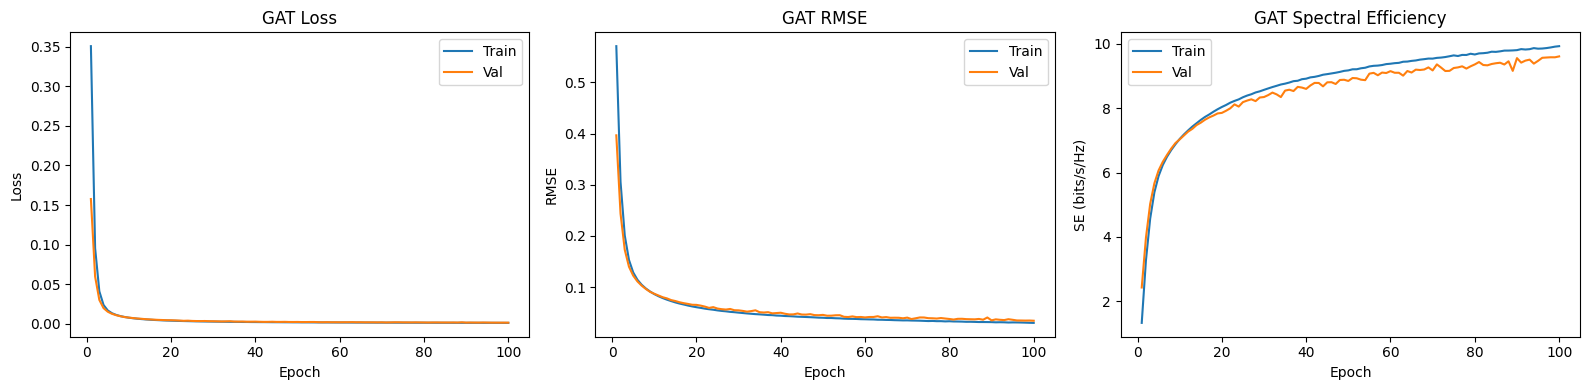

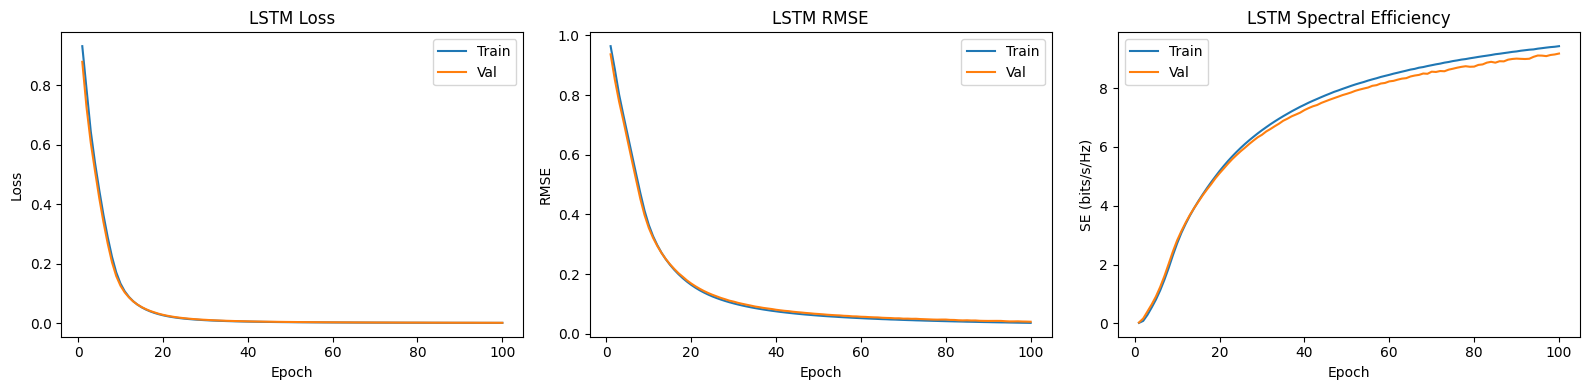

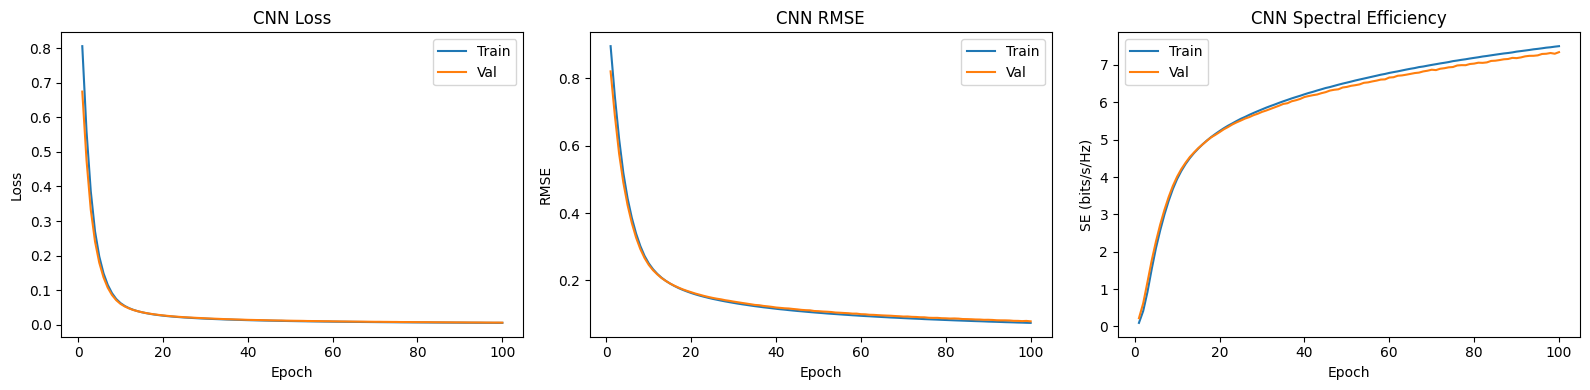

In [23]:
def plot_curves(history, model_name='Model'):
    epochs = range(1, len(history['train_loss'])+1)
    plt.figure(figsize=(16,4))
    plt.subplot(1,3,1)
    plt.plot(epochs, history['train_loss'], label='Train')
    plt.plot(epochs, history['val_loss'], label='Val')
    plt.title(f'{model_name} Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.subplot(1,3,2)
    plt.plot(epochs, history['train_rmse'], label='Train')
    plt.plot(epochs, history['val_rmse'], label='Val')
    plt.title(f'{model_name} RMSE')
    plt.xlabel('Epoch')
    plt.ylabel('RMSE')
    plt.legend()

    plt.subplot(1,3,3)
    plt.plot(epochs, history['train_se'], label='Train')
    plt.plot(epochs, history['val_se'], label='Val')
    plt.title(f'{model_name} Spectral Efficiency')
    plt.xlabel('Epoch')
    plt.ylabel('SE (bits/s/Hz)')
    plt.legend()
    plt.tight_layout()
    plt.savefig(f'{model_name.lower()}_train_val_curves.png', dpi=300)
    plt.show()

plot_curves(gat_history, 'GAT')
plot_curves(lstm_history, 'LSTM')
plot_curves(cnn_history, 'CNN')


In [20]:
def evaluate_se_vs_ebn0(model, loader, device, ebn0_db_range):
    se_list = []
    model.eval()
    with torch.no_grad():
        for ebn0 in ebn0_db_range:
            total_se = 0
            count = 0
            for x, y in loader:
                x = x.to(device)
                y_true = y[:, -1, :OUTPUT_DIM].cpu().numpy()
                y_pred = model(x).cpu().numpy()
                se = spectral_efficiency(y_true, y_pred, snr_db=ebn0)
                total_se += se
                count += 1
            se_list.append(total_se / count)
    return se_list

ebn0_db_range = np.arange(0, 21, 2)

# Reload best models
gat_best = EnhancedGAT().to(DEVICE)
gat_best.load_state_dict(torch.load('gat_best.pth', map_location=DEVICE))
lstm_best = LSTMNet().to(DEVICE)
lstm_best.load_state_dict(torch.load('lstm_best.pth', map_location=DEVICE))
cnn_best = CNNNet().to(DEVICE)
cnn_best.load_state_dict(torch.load('cnn_best.pth', map_location=DEVICE))

gat_test_se = evaluate_se_vs_ebn0(gat_best, test_loader, DEVICE, ebn0_db_range)
lstm_test_se = evaluate_se_vs_ebn0(lstm_best, test_loader, DEVICE, ebn0_db_range)
cnn_test_se = evaluate_se_vs_ebn0(cnn_best, test_loader, DEVICE, ebn0_db_range)


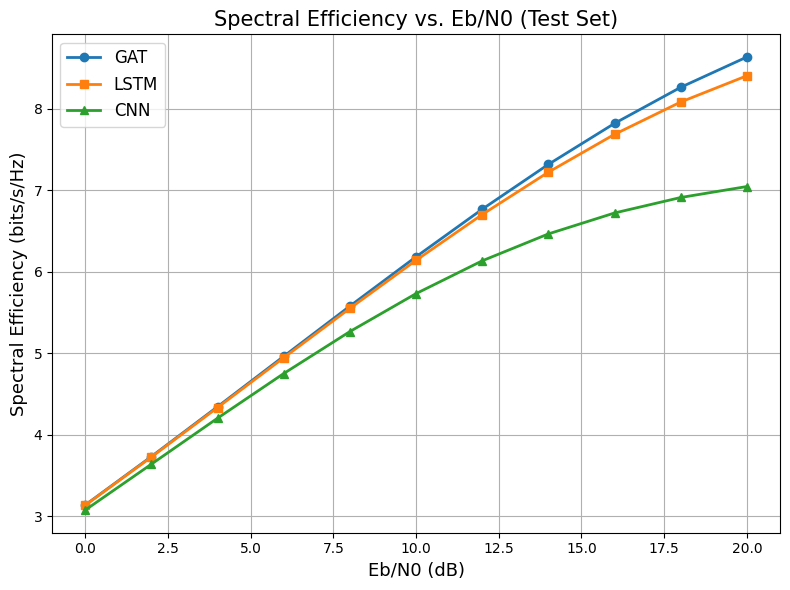

In [21]:
plt.figure(figsize=(8,6))
plt.plot(ebn0_db_range, gat_test_se, marker='o', linewidth=2, label='GAT')
plt.plot(ebn0_db_range, lstm_test_se, marker='s', linewidth=2, label='LSTM')
plt.plot(ebn0_db_range, cnn_test_se, marker='^', linewidth=2, label='CNN')
plt.xlabel('Eb/N0 (dB)', fontsize=13)
plt.ylabel('Spectral Efficiency (bits/s/Hz)', fontsize=13)
plt.title('Spectral Efficiency vs. Eb/N0 (Test Set)', fontsize=15)
plt.grid(True)
plt.legend(fontsize=12)
plt.tight_layout()
plt.savefig('model_comparison_se_vs_ebn0.png', dpi=300)
plt.show()


In [22]:
gat_loss, gat_rmse, gat_se = validate(gat_best, test_loader, DEVICE)
lstm_loss, lstm_rmse, lstm_se = validate(lstm_best, test_loader, DEVICE)
cnn_loss, cnn_rmse, cnn_se = validate(cnn_best, test_loader, DEVICE)
print("\nFinal Test Results (Eb/N0=30dB):")
print(f"GAT  | Loss: {gat_loss:.4f} | RMSE: {gat_rmse:.4f} | SE: {gat_se:.4f}")
print(f"LSTM | Loss: {lstm_loss:.4f} | RMSE: {lstm_rmse:.4f} | SE: {lstm_se:.4f}")
print(f"CNN  | Loss: {cnn_loss:.4f} | RMSE: {cnn_rmse:.4f} | SE: {cnn_se:.4f}")

print("\nEb/N0 (dB)\tGAT SE\tLSTM SE\tCNN SE")
for ebn0, gse, lse, cse in zip(ebn0_db_range, gat_test_se, lstm_test_se, cnn_test_se):
    print(f"{ebn0}\t\t{gse:.4f}\t{lse:.4f}\t{cse:.4f}")



Final Test Results (Eb/N0=30dB):
GAT  | Loss: 0.0012 | RMSE: 0.0351 | SE: 9.5054
LSTM | Loss: 0.0017 | RMSE: 0.0408 | SE: 9.1060
CNN  | Loss: 0.0062 | RMSE: 0.0787 | SE: 7.2785

Eb/N0 (dB)	GAT SE	LSTM SE	CNN SE
0		3.1359	3.1325	3.0739
2		3.7306	3.7245	3.6373
4		4.3419	4.3314	4.2012
6		4.9600	4.9427	4.7490
8		5.5761	5.5485	5.2639
10		6.1811	6.1381	5.7295
12		6.7647	6.6996	6.1317
14		7.3148	7.2194	6.4618
16		7.8178	7.6834	6.7185
18		8.2603	8.0798	6.9085
20		8.6319	8.4018	7.0429
